# arXiv LLM Keyword Trend Analysis & Forecasting

This notebook tracks the emergence and growth of Large Language Model (LLM) related keywords
in the arXiv CS literature (cs.AI / cs.CL / cs.LG) and forecasts future paper volume using
ARIMA and Prophet.

**Pipeline:**
1. Load data with DuckDB from `arxiv_sample.parquet` + `abstracts_parsed.parquet`
2. Filter to cs.AI / cs.CL / cs.LG papers
3. Extract submission dates from the `versions` column (v1 date = original submission)
4. Track monthly keyword emergence (transformer, RLHF, RAG, LoRA, etc.)
5. Forecast monthly paper volume with ARIMA and Prophet

## 1. Imports & Setup

In [1]:
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

SEED = 42
np.random.seed(SEED)
print('All imports successful.')

All imports successful.


## 2. Load Data with DuckDB

In [2]:
con = duckdb.connect()

# Register parquet files as virtual tables
con.execute("CREATE VIEW arxiv AS SELECT * FROM read_parquet('arxiv_sample.parquet')")
con.execute("CREATE VIEW abstracts AS SELECT * FROM read_parquet('abstracts_parsed.parquet')")

print("arxiv_sample columns:", con.execute("DESCRIBE arxiv").df()['column_name'].tolist())
print("abstracts_parsed columns:", con.execute("DESCRIBE abstracts").df()['column_name'].tolist())
print("\narxiv row count:", con.execute("SELECT COUNT(*) FROM arxiv").fetchone()[0])
print("abstracts row count:", con.execute("SELECT COUNT(*) FROM abstracts").fetchone()[0])

arxiv_sample columns: ['id', 'submitter', 'authors', 'title', 'comments', 'journal-ref', 'doi', 'report-no', 'categories', 'license', 'abstract', 'versions', 'update_date', 'authors_parsed']
abstracts_parsed columns: ['id', 'abstract_raw', 'abstract_tokens_clean', 'abstract_clean', 'abstract_token_count']

arxiv row count: 301488
abstracts row count: 301488


## 3. Filter to cs.AI / cs.CL / cs.LG and Extract Submission Dates

The `versions` column stores a list of dicts.  The v1 entry gives the **original** submission date
which is the most meaningful timestamp for trend analysis (not the update date).
We parse it in Python after pulling the filtered rows.

In [3]:
# Pull all cs.AI/cs.CL/cs.LG papers with their abstracts
query = """
SELECT
    a.id,
    a.categories,
    a.versions,
    a.update_date,
    a.title,
    a.abstract,
    p.abstract_clean
FROM arxiv a
LEFT JOIN abstracts p ON a.id = p.id
WHERE
    regexp_matches(a.categories, '(^| )(cs\\.AI|cs\\.CL|cs\\.LG)( |$)')
"""

df_raw = con.execute(query).df()
print(f"Filtered rows: {len(df_raw):,}")
df_raw.head(3)

Filtered rows: 41,417


,id,categories,versions,update_date,title,abstract,abstract_clean
0,0704.1409,cs.LG cs.AI,"[{'created': 'Wed, 11 Apr 2007 13:17:01 GMT', ...",2012-06-11,Preconditioned Temporal Difference Learning,This paper has been withdrawn by the author....,withdrawn author draft withdrawn poor quality ...
1,0704.3905,cs.AI,"[{'created': 'Mon, 30 Apr 2007 09:29:22 GMT', ...",2007-05-23,Ensemble Learning for Free with Evolutionary A...,Evolutionary Learning proceeds by evolving a...,evolutionary learn proceeds evolve population ...
2,0705.0462,math.CT cs.CL,"[{'created': 'Thu, 3 May 2007 13:44:54 GMT', '...",2007-05-23,Resource modalities in game semantics,The description of resources in game semanti...,description resource game semantics never achi...


In [4]:
def extract_v1_date(versions):
    """Parse the 'created' field of the v1 entry from the versions list."""
    try:
        if isinstance(versions, (list, np.ndarray)):
            for entry in versions:
                if isinstance(entry, dict) and entry.get('version') == 'v1':
                    return pd.to_datetime(entry['created'], utc=True)
        return pd.NaT
    except Exception:
        return pd.NaT


df_raw['submitted'] = df_raw['versions'].apply(extract_v1_date)
df_raw['submitted'] = pd.to_datetime(df_raw['submitted'], utc=True).dt.tz_localize(None)

# Drop rows with no parsable date
df = df_raw.dropna(subset=['submitted']).copy()
df['year']       = df['submitted'].dt.year
df['year_month'] = df['submitted'].dt.to_period('M')

# Limit to reasonable range (2007-present)
df = df[(df['year'] >= 2007) & (df['year'] <= 2025)]

print(f"Papers with valid submission date: {len(df):,}")
print(f"Date range: {df['submitted'].min().date()} → {df['submitted'].max().date()}")
print(f"\nPrimary category breakdown:")
print(df['categories'].str.split().str[0].value_counts().head(10))

Papers with valid submission date: 38,480
Date range: 2007-01-05 → 2025-12-31

Primary category breakdown:
categories
cs.LG      12268
cs.CL       7324
cs.CV       3893
cs.AI       3194
stat.ML     1643
cs.RO        926
cs.CR        713
cs.IR        636
eess.IV      590
cs.SD        550
Name: count, dtype: int64


## 4. Keyword Definitions

Each keyword is matched against the **raw abstract** (case-insensitive, word-boundary aware)
so that e.g. "RLHF" matches the acronym and "reinforcement learning from human feedback" matches
the long form.

In [5]:
KEYWORDS = {
    # Architecture primitives
    'Transformer':          r'\btransformer\b',
    'Attention':            r'\bself[- ]attention\b|\bmulti[- ]head attention\b',
    'BERT':                 r'\bBERT\b',
    'GPT':                  r'\bGPT[- ]?\d?\b|\bgenerative pre[- ]trained\b',
    # Alignment & fine-tuning
    'RLHF':                 r'\bRLHF\b|reinforcement learning from human feedback',
    'LoRA':                 r'\bLoRA\b|low[- ]rank adaptation',
    'Instruction Tuning':   r'instruction[- ]tun|instruction following',
    'PEFT':                 r'\bPEFT\b|parameter[- ]efficient fine[- ]tun',
    # Retrieval & grounding
    'RAG':                  r'\bRAG\b|retrieval[- ]augmented generation',
    'Chain-of-Thought':     r'chain[- ]of[- ]thought|\bCoT\b',
    'In-Context Learning':  r'in[- ]context learn',
    # Deployment & efficiency
    'Quantization':         r'\bquantiz',
    'Knowledge Distill.':   r'knowledge distill',
    'Prompt Engineering':   r'prompt engineer|prompt design|prompt optim',
    # Multimodal
    'Multimodal LLM':       r'multimodal.*(?:llm|language model)|vision[- ]language model',
    'Diffusion Model':      r'diffusion model|denoising diffusion',
    # General LLM term
    'LLM':                  r'\bLLM\b|large language model',
}

# Compile all patterns (case-insensitive)
compiled = {kw: re.compile(pat, re.IGNORECASE) for kw, pat in KEYWORDS.items()}

# Search in raw abstract (preserves acronyms like RLHF / LoRA / GPT)
text_col = df['abstract'].fillna('')

for kw, pattern in compiled.items():
    df[kw] = text_col.str.contains(pattern, regex=True).astype(int)

keyword_cols = list(KEYWORDS.keys())
print("Keyword hit counts across cs.AI/CL/LG corpus:")
print(df[keyword_cols].sum().sort_values(ascending=False).to_string())

Keyword hit counts across cs.AI/CL/LG corpus:
LLM                    4689
Transformer            1855
GPT                    1017
Diffusion Model         678
Multimodal LLM          629
BERT                    601
Quantization            496
Attention               409
RAG                     347
Chain-of-Thought        344
Knowledge Distill.      251
In-Context Learning     242
Instruction Tuning      225
LoRA                    215
Prompt Engineering      185
RLHF                    115
PEFT                    114


## 5. Monthly Paper Volume Over Time

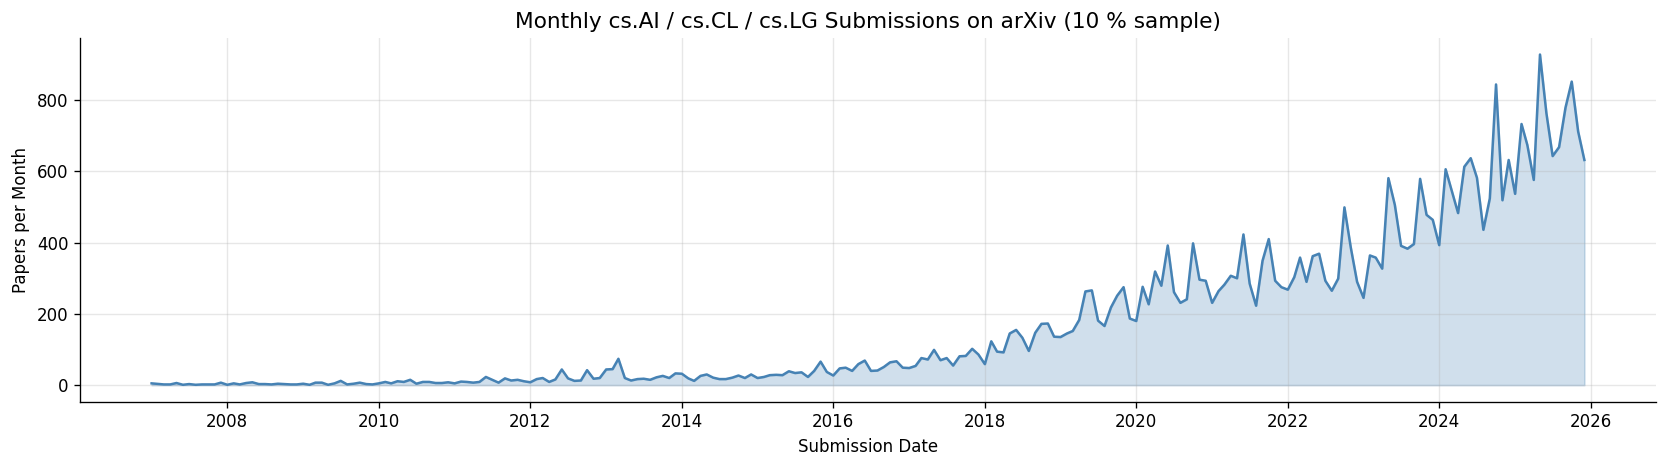

In [6]:
monthly_total = (
    df.groupby('year_month')
    .size()
    .rename('paper_count')
    .reset_index()
)
monthly_total['date'] = monthly_total['year_month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(monthly_total['date'], monthly_total['paper_count'], alpha=0.25, color='steelblue')
ax.plot(monthly_total['date'], monthly_total['paper_count'], color='steelblue', linewidth=1.5)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_title('Monthly cs.AI / cs.CL / cs.LG Submissions on arXiv (10 % sample)', fontsize=13)
ax.set_xlabel('Submission Date')
ax.set_ylabel('Papers per Month')
plt.tight_layout()
plt.show()

## 6. Keyword Emergence Over Time

We look at two complementary views:
- **Absolute count** — raw mentions per month
- **Share of monthly corpus** — keyword mentions ÷ total papers that month (normalises for growth)

In [7]:
monthly_kw = (
    df.groupby('year_month')[keyword_cols]
    .sum()
    .reset_index()
)
monthly_kw['date'] = monthly_kw['year_month'].dt.to_timestamp()

# Merge with total to compute share
monthly_kw = monthly_kw.merge(monthly_total[['year_month', 'paper_count']], on='year_month')

share_cols = {}
for kw in keyword_cols:
    share_col = kw + '_share'
    monthly_kw[share_col] = monthly_kw[kw] / monthly_kw['paper_count']
    share_cols[kw] = share_col

monthly_kw.head(3)

,year_month,Transformer,Attention,BERT,GPT,RLHF,LoRA,Instruction Tuning,PEFT,RAG,...,PEFT_share,RAG_share,Chain-of-Thought_share,In-Context Learning_share,Quantization_share,Knowledge Distill._share,Prompt Engineering_share,Multimodal LLM_share,Diffusion Model_share,LLM_share
0,2007-01,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2007-03,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2007-04,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


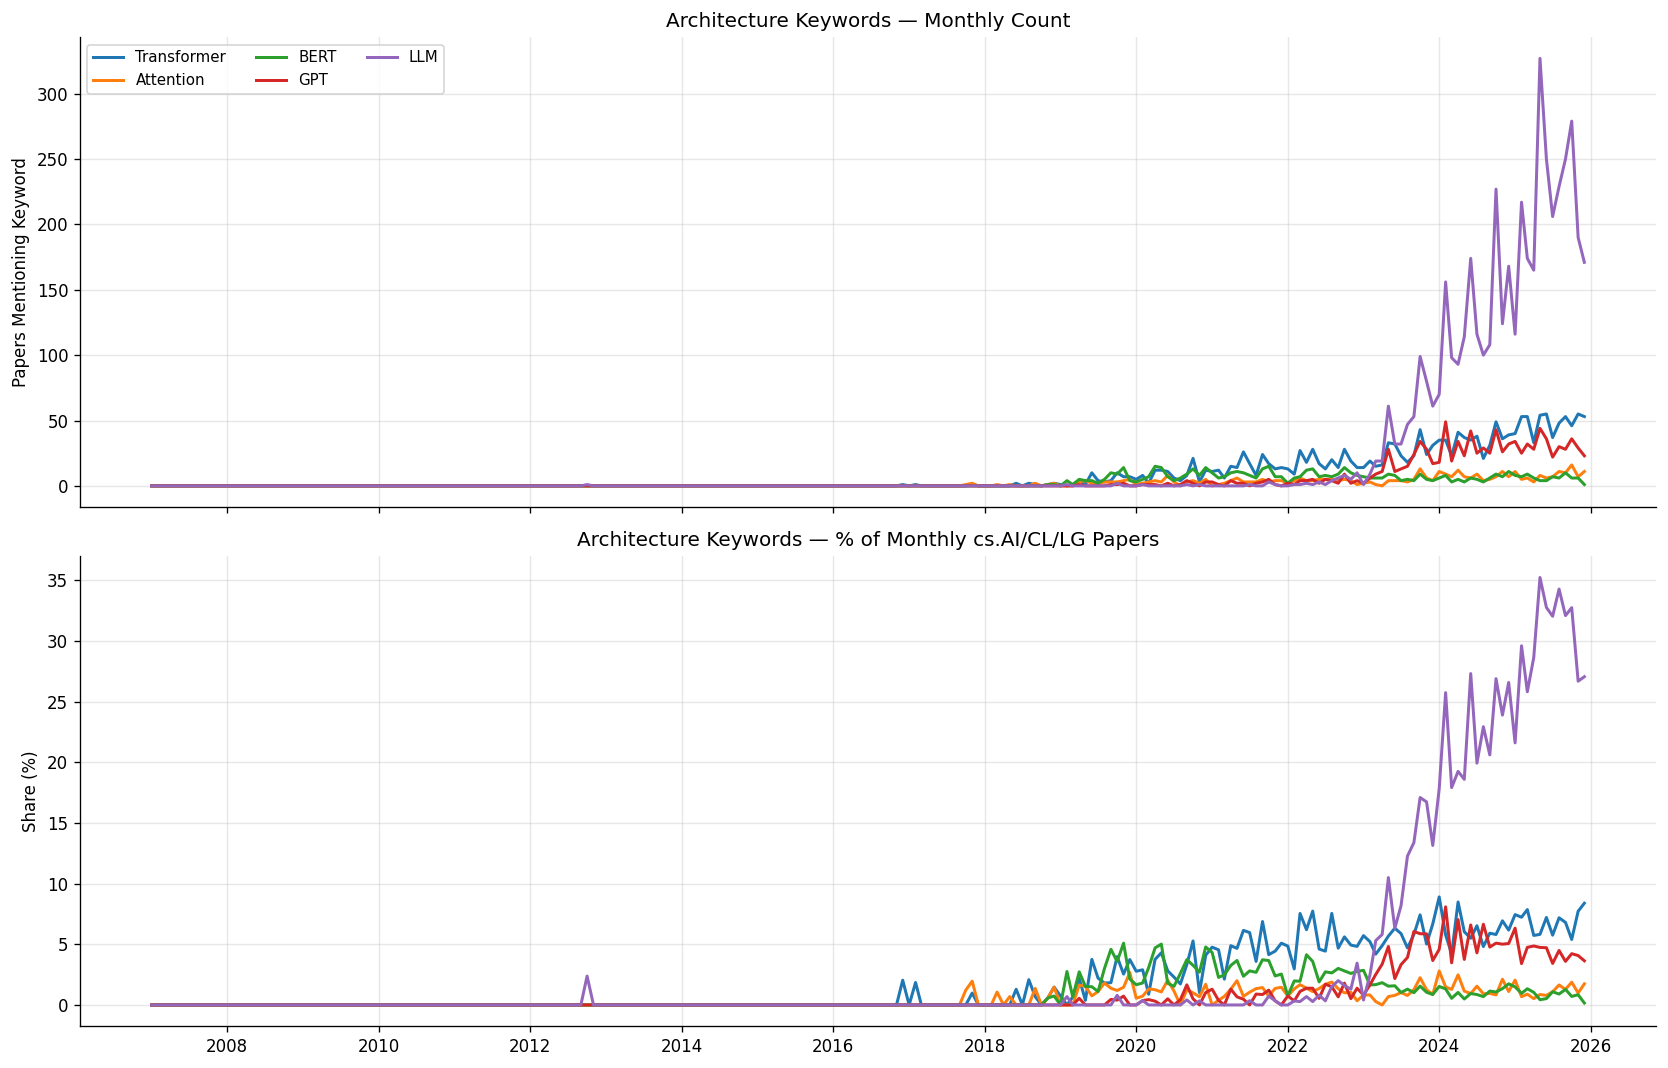

In [8]:
# ── Group 1: Foundational architecture keywords ──────────────────────────────
arch_kws = ['Transformer', 'Attention', 'BERT', 'GPT', 'LLM']

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

cmap = plt.cm.tab10.colors
for i, kw in enumerate(arch_kws):
    axes[0].plot(monthly_kw['date'], monthly_kw[kw],
                 label=kw, color=cmap[i], linewidth=1.8)
    axes[1].plot(monthly_kw['date'], monthly_kw[share_cols[kw]] * 100,
                 label=kw, color=cmap[i], linewidth=1.8)

axes[0].set_title('Architecture Keywords — Monthly Count', fontsize=12)
axes[0].set_ylabel('Papers Mentioning Keyword')
axes[0].legend(ncol=3, fontsize=9)

axes[1].set_title('Architecture Keywords — % of Monthly cs.AI/CL/LG Papers', fontsize=12)
axes[1].set_ylabel('Share (%)')
axes[1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

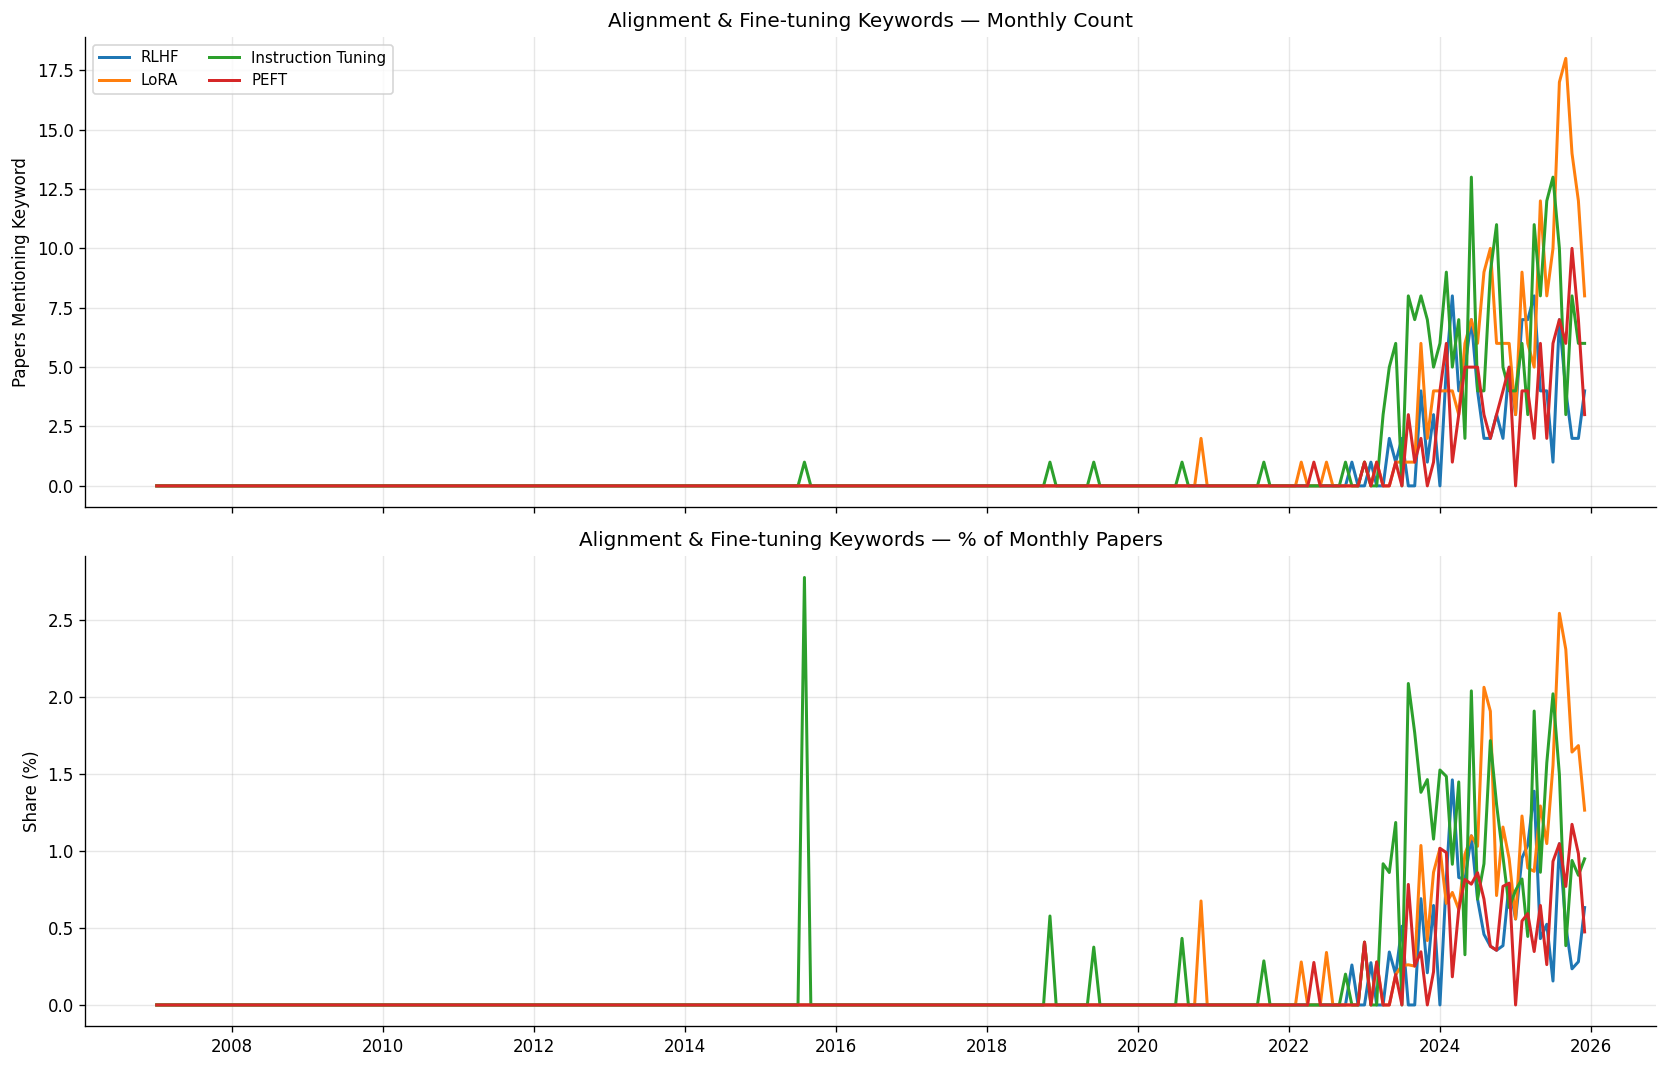

In [9]:
# ── Group 2: Alignment & Fine-tuning techniques ───────────────────────────────
align_kws = ['RLHF', 'LoRA', 'Instruction Tuning', 'PEFT']

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

for i, kw in enumerate(align_kws):
    axes[0].plot(monthly_kw['date'], monthly_kw[kw],
                 label=kw, color=cmap[i], linewidth=1.8)
    axes[1].plot(monthly_kw['date'], monthly_kw[share_cols[kw]] * 100,
                 label=kw, color=cmap[i], linewidth=1.8)

axes[0].set_title('Alignment & Fine-tuning Keywords — Monthly Count', fontsize=12)
axes[0].set_ylabel('Papers Mentioning Keyword')
axes[0].legend(ncol=2, fontsize=9)

axes[1].set_title('Alignment & Fine-tuning Keywords — % of Monthly Papers', fontsize=12)
axes[1].set_ylabel('Share (%)')
axes[1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

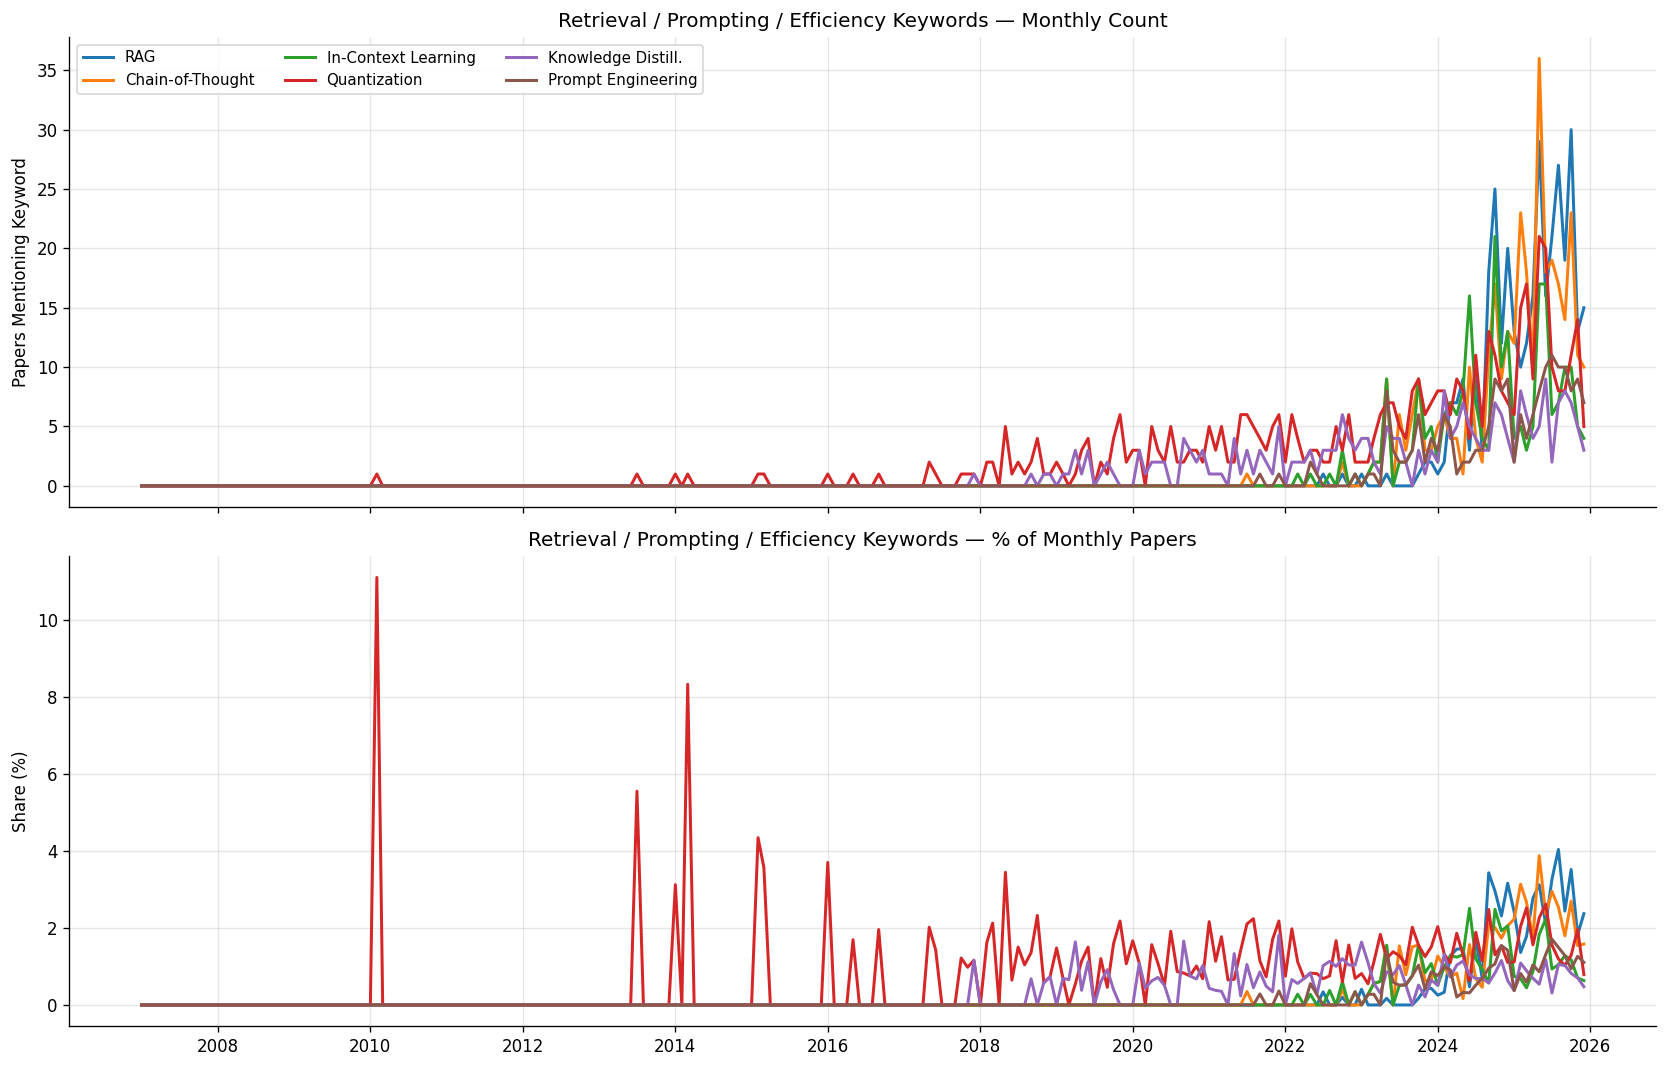

In [10]:
# ── Group 3: Retrieval, Prompting & Efficiency ───────────────────────────────
ret_kws = ['RAG', 'Chain-of-Thought', 'In-Context Learning',
           'Quantization', 'Knowledge Distill.', 'Prompt Engineering']

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

for i, kw in enumerate(ret_kws):
    axes[0].plot(monthly_kw['date'], monthly_kw[kw],
                 label=kw, color=cmap[i], linewidth=1.8)
    axes[1].plot(monthly_kw['date'], monthly_kw[share_cols[kw]] * 100,
                 label=kw, color=cmap[i], linewidth=1.8)

axes[0].set_title('Retrieval / Prompting / Efficiency Keywords — Monthly Count', fontsize=12)
axes[0].set_ylabel('Papers Mentioning Keyword')
axes[0].legend(ncol=3, fontsize=9)

axes[1].set_title('Retrieval / Prompting / Efficiency Keywords — % of Monthly Papers', fontsize=12)
axes[1].set_ylabel('Share (%)')
axes[1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

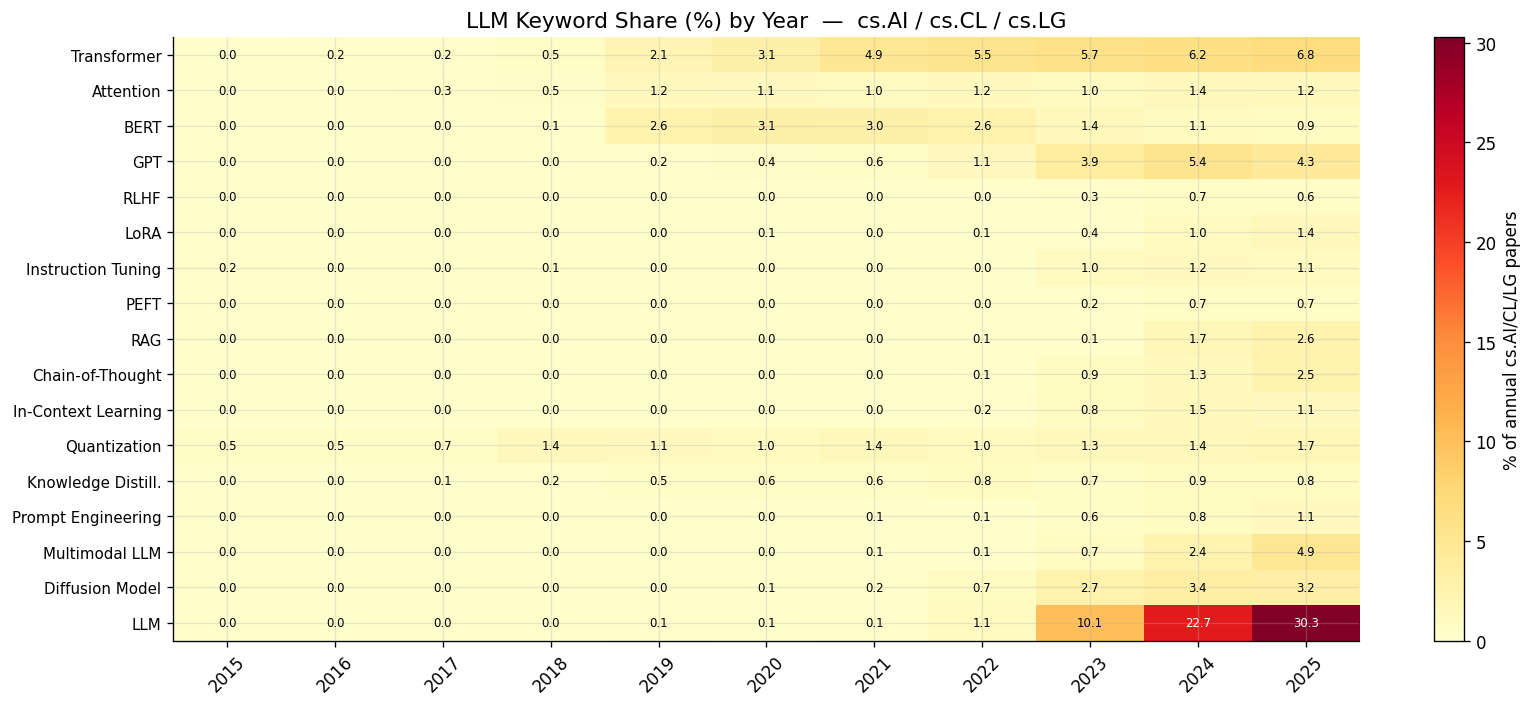

In [11]:
# ── Heatmap: keyword × year (share of annual corpus) ─────────────────────────
annual_kw = df.groupby('year')[keyword_cols].sum()
annual_total = df.groupby('year').size().rename('total')
annual_share = annual_kw.div(annual_total, axis=0) * 100   # percent

# Keep 2015-2025 for readability
annual_share = annual_share.loc[2015:2025]

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(annual_share.T.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
plt.colorbar(im, ax=ax, label='% of annual cs.AI/CL/LG papers')

ax.set_xticks(range(len(annual_share.index)))
ax.set_xticklabels(annual_share.index, rotation=45)
ax.set_yticks(range(len(keyword_cols)))
ax.set_yticklabels(keyword_cols, fontsize=9)
ax.set_title('LLM Keyword Share (%) by Year  —  cs.AI / cs.CL / cs.LG', fontsize=13)

# Annotate cells
for i, kw in enumerate(keyword_cols):
    for j, yr in enumerate(annual_share.index):
        val = annual_share.loc[yr, kw]
        ax.text(j, i, f'{val:.1f}', ha='center', va='center',
                fontsize=7, color='black' if val < 15 else 'white')

plt.tight_layout()
plt.show()

## 7. Keyword First-Emergence Timeline

For each keyword, find the **first month** it appeared in this corpus.

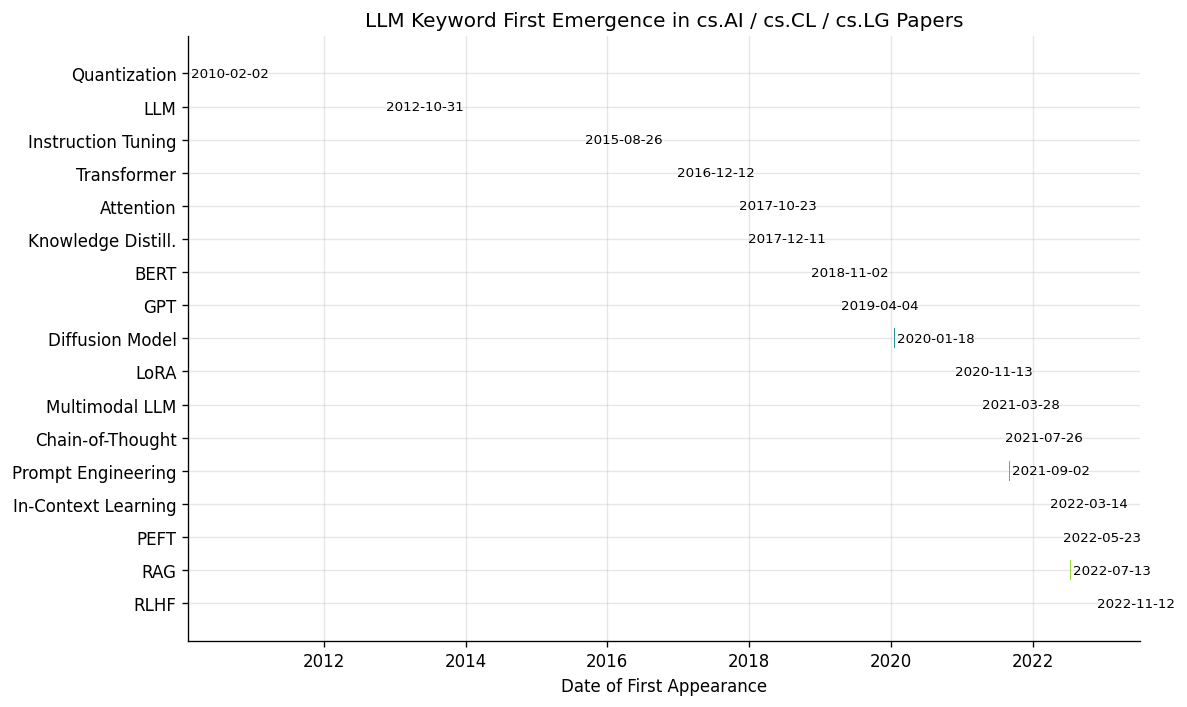

                     first_seen
Quantization         2010-02-02
LLM                  2012-10-31
Instruction Tuning   2015-08-26
Transformer          2016-12-12
Attention            2017-10-23
Knowledge Distill.   2017-12-11
BERT                 2018-11-02
GPT                  2019-04-04
Diffusion Model      2020-01-18
LoRA                 2020-11-13
Multimodal LLM       2021-03-28
Chain-of-Thought     2021-07-26
Prompt Engineering   2021-09-02
In-Context Learning  2022-03-14
PEFT                 2022-05-23
RAG                  2022-07-13
RLHF                 2022-11-12


In [12]:
emergence = {}
for kw in keyword_cols:
    hits = df[df[kw] == 1]['submitted']
    if len(hits):
        emergence[kw] = hits.min().date()

emergence_df = (
    pd.DataFrame.from_dict(emergence, orient='index', columns=['first_seen'])
    .sort_values('first_seen')
)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(emergence_df)))

for i, (kw, row) in enumerate(emergence_df.iterrows()):
    ax.barh(kw, 1, left=mdates.date2num(row['first_seen']), color=colors[i], height=0.6)
    ax.text(mdates.date2num(row['first_seen']) + 15, i, str(row['first_seen']),
            va='center', fontsize=8)

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_xlabel('Date of First Appearance')
ax.set_title('LLM Keyword First Emergence in cs.AI / cs.CL / cs.LG Papers', fontsize=12)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(emergence_df.to_string())

## 8. Year-over-Year Growth Rate

Compare annual keyword counts to identify the fastest-growing topics.

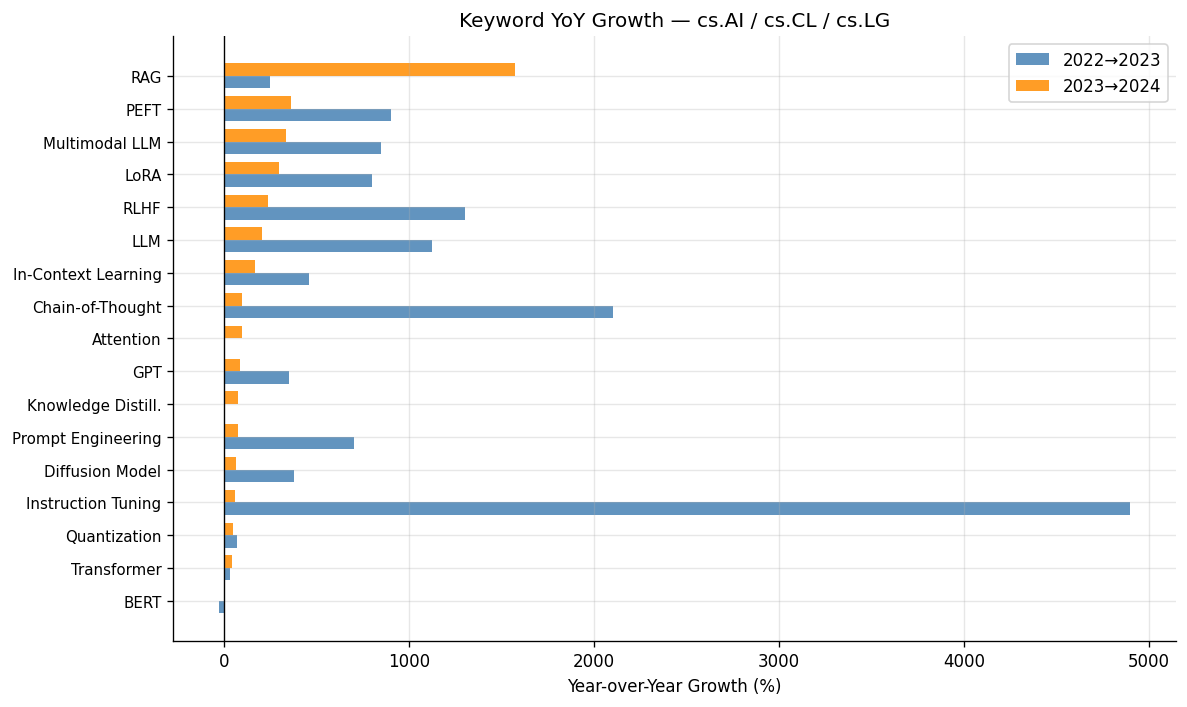

                     2022→2023 (%)  2023→2024 (%)
BERT                    -29.126214      -1.369863
Transformer              32.272727      44.329897
Quantization             67.500000      46.268657
Instruction Tuning     4900.000000      58.000000
Diffusion Model         379.310345      64.748201
Prompt Engineering      700.000000      75.000000
Knowledge Distill.        3.125000      75.757576
GPT                     350.000000      84.343434
Attention                 0.000000      93.877551
Chain-of-Thought       2100.000000      95.454545
In-Context Learning     457.142857     164.102564
LLM                    1121.428571     201.754386
RLHF                   1300.000000     235.714286
LoRA                    800.000000     294.444444
Multimodal LLM          850.000000     331.578947
PEFT                    900.000000     360.000000
RAG                     250.000000    1571.428571


In [13]:
# Compute YoY growth between 2022 → 2023 and 2023 → 2024
yoy_years = [2022, 2023, 2024]
annual_abs = annual_kw.loc[yoy_years]

growth_22_23 = ((annual_abs.loc[2023] - annual_abs.loc[2022]) / annual_abs.loc[2022].replace(0, np.nan) * 100)
growth_23_24 = ((annual_abs.loc[2024] - annual_abs.loc[2023]) / annual_abs.loc[2023].replace(0, np.nan) * 100)

growth_df = pd.DataFrame({
    '2022→2023 (%)': growth_22_23,
    '2023→2024 (%)': growth_23_24,
}).dropna().sort_values('2023→2024 (%)', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(growth_df))
width = 0.38
ax.barh(x - width/2, growth_df['2022→2023 (%)'], width, label='2022→2023', color='steelblue', alpha=0.85)
ax.barh(x + width/2, growth_df['2023→2024 (%)'], width, label='2023→2024', color='darkorange', alpha=0.85)
ax.set_yticks(x)
ax.set_yticklabels(growth_df.index, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Year-over-Year Growth (%)')
ax.set_title('Keyword YoY Growth — cs.AI / cs.CL / cs.LG', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

print(growth_df.to_string())

## 9. Forecasting — Prepare Time Series

We use **monthly paper volume** (all cs.AI/CL/LG) as the target.  
Train on 2015–2023, forecast 2024 onward and compare to actuals.

Train: 2015-01-31 → 2023-12-31  (108 months)
Test : 2024-01-31  → 2025-12-31   (24 months)


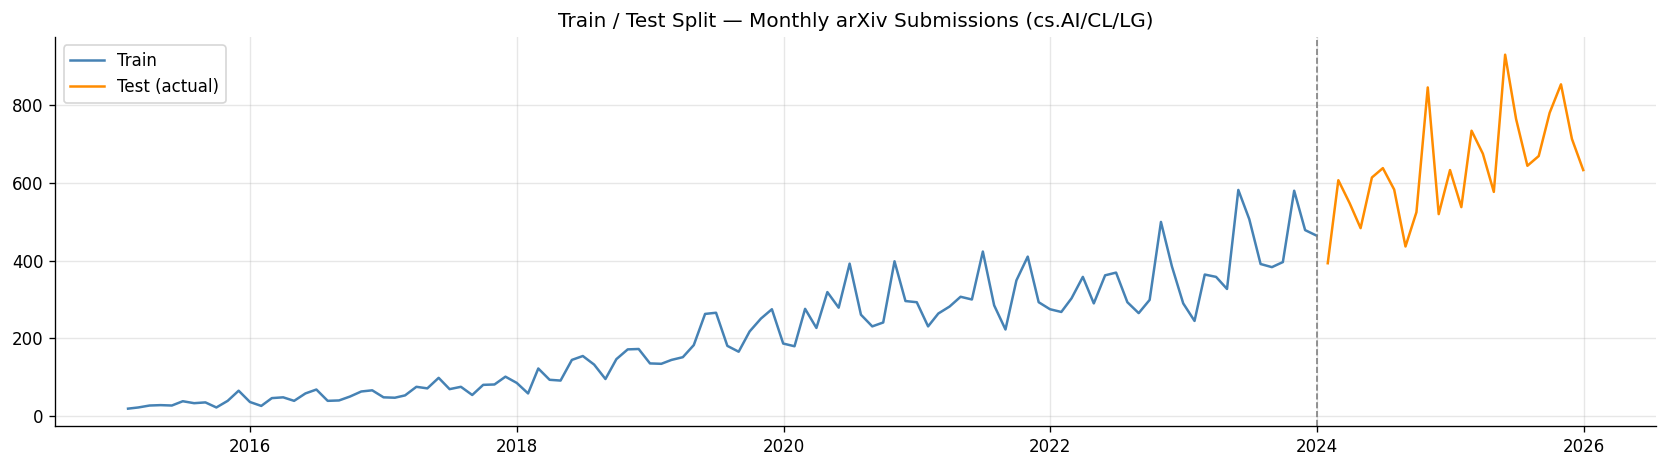

In [14]:
# Build monthly series with a complete datetime index
ts = monthly_total.set_index('date')['paper_count'].sort_index()
ts.index = pd.DatetimeIndex(ts.index).to_period('M').to_timestamp('M')  # month-end
ts = ts[ts.index >= '2015-01-01']   # plenty of history, avoids sparse early years

# Train / test split
TRAIN_END = '2023-12-31'
TEST_START = '2024-01-01'

train = ts[ts.index <= TRAIN_END]
test  = ts[ts.index >= TEST_START]

print(f"Train: {train.index[0].date()} → {train.index[-1].date()}  ({len(train)} months)")
print(f"Test : {test.index[0].date()}  → {test.index[-1].date()}   ({len(test)} months)")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train.index, train, label='Train', color='steelblue')
ax.plot(test.index,  test,  label='Test (actual)', color='darkorange')
ax.axvline(pd.Timestamp(TEST_START), color='grey', linestyle='--', linewidth=1)
ax.set_title('Train / Test Split — Monthly arXiv Submissions (cs.AI/CL/LG)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

### 9.1  Stationarity Check (ADF Test)

In [15]:
def adf_report(series, label=''):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f"{'─'*50}")
    print(f"ADF Test: {label}")
    print(f"  Statistic : {result[0]:.4f}")
    print(f"  p-value   : {result[1]:.4f}")
    print(f"  Stationary: {'YES ✓' if result[1] < 0.05 else 'NO  — differencing needed'}")

adf_report(train, 'Raw monthly count')
adf_report(train.diff().dropna(), '1st-order difference')

──────────────────────────────────────────────────
ADF Test: Raw monthly count
  Statistic : 1.2983
  p-value   : 0.9966
  Stationary: NO  — differencing needed
──────────────────────────────────────────────────
ADF Test: 1st-order difference
  Statistic : -1.7225
  p-value   : 0.4196
  Stationary: NO  — differencing needed


### 9.2  ACF / PACF Plots

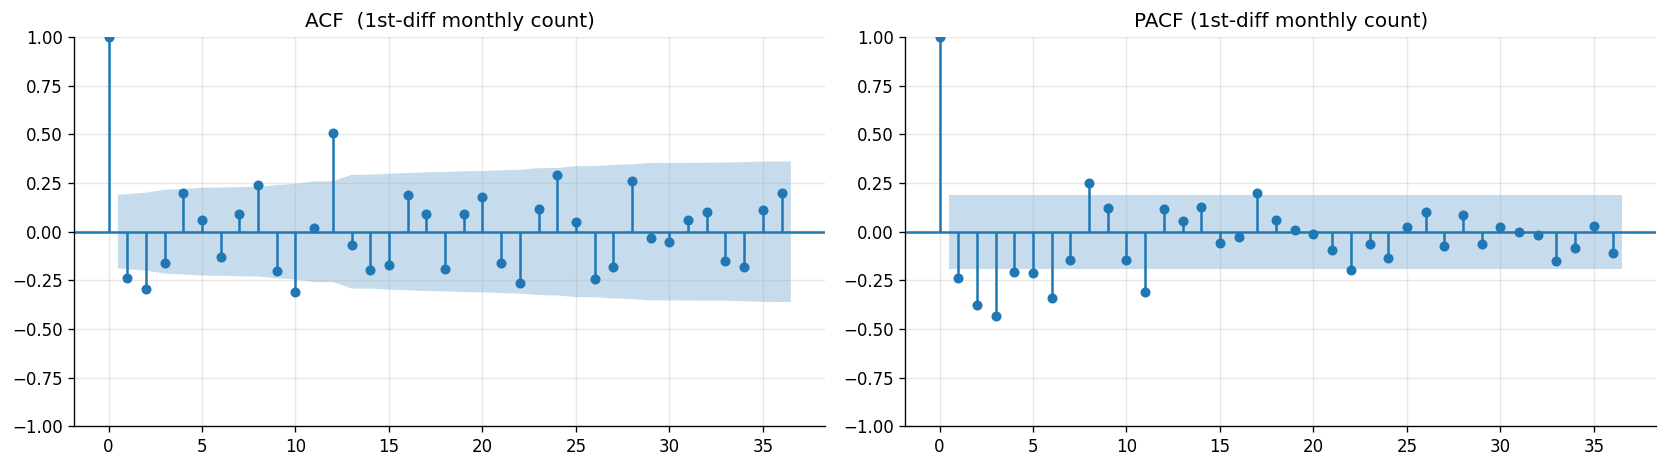

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(train.diff().dropna(),  lags=36, ax=axes[0], title='ACF  (1st-diff monthly count)')
plot_pacf(train.diff().dropna(), lags=36, ax=axes[1], title='PACF (1st-diff monthly count)',
          method='ywm')
plt.tight_layout()
plt.show()

## 10. ARIMA Forecast

In [17]:
# SARIMA(1,1,1)(1,0,1)[12]  — seasonal period 12 months
# d=1 because ADF showed non-stationarity; mild seasonal component from ACF
arima_model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
arima_fit = arima_model.fit(disp=False)
print(arima_fit.summary().tables[0])

                                     SARIMAX Results                                      
Dep. Variable:                        paper_count   No. Observations:                  108
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 12)   Log Likelihood                -474.722
Date:                            Mon, 13 Apr 2026   AIC                            959.445
Time:                                    20:00:08   BIC                            972.108
Sample:                                01-31-2015   HQIC                           964.558
                                     - 12-31-2023                                         
Covariance Type:                              opg                                         


c:\Users\geonk\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\geonk\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


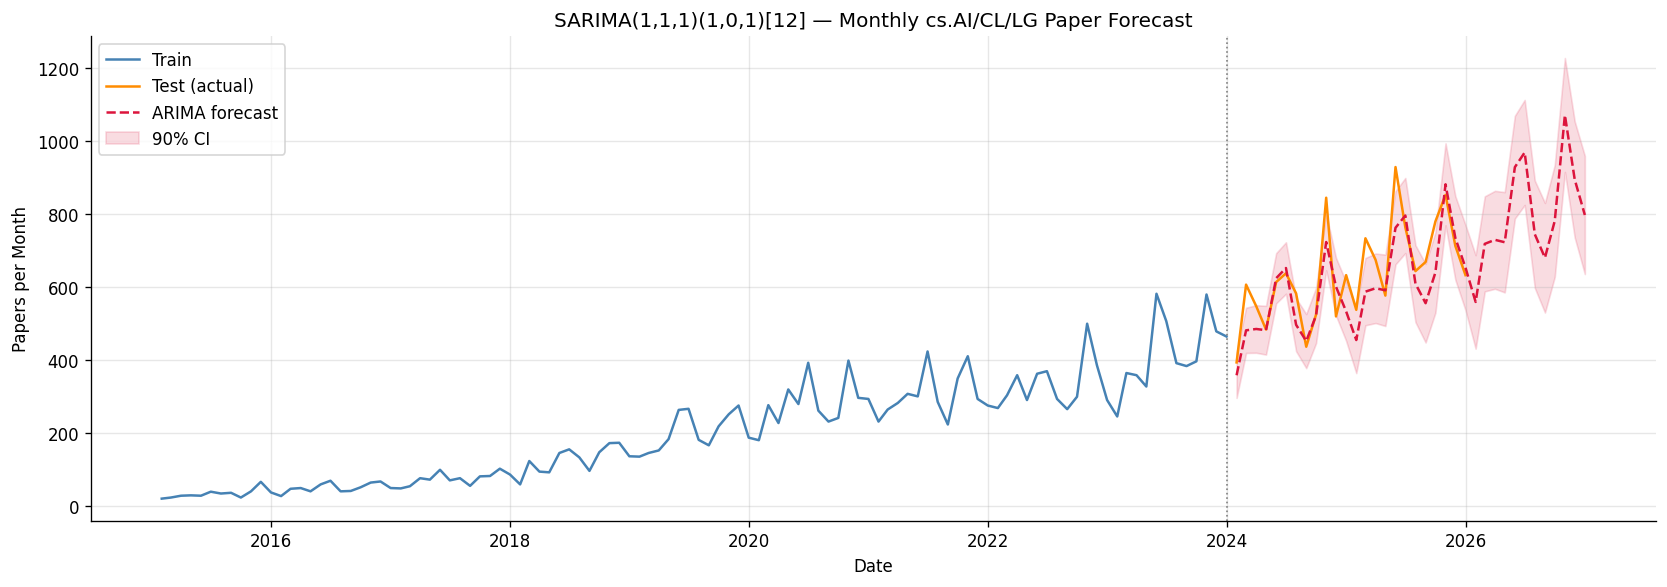


ARIMA Test-set Metrics
  MAE  : 63.9 papers/month
  RMSE : 81.2 papers/month
  MAPE : 9.6%


In [18]:
# Forecast for the test horizon + 12 months beyond
N_FORECAST = len(test) + 12

arima_pred = arima_fit.get_forecast(steps=N_FORECAST)
arima_mean = arima_pred.predicted_mean
arima_ci   = arima_pred.conf_int(alpha=0.1)   # 90 % CI

# Build future date index
future_idx = pd.date_range(
    start=train.index[-1] + pd.DateOffset(months=1),
    periods=N_FORECAST,
    freq='ME'
)
arima_mean.index = future_idx
arima_ci.index   = future_idx

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index, train, label='Train', color='steelblue', linewidth=1.5)
ax.plot(test.index,  test,  label='Test (actual)', color='darkorange', linewidth=1.5)
ax.plot(arima_mean.index, arima_mean, label='ARIMA forecast', color='crimson',
        linewidth=1.5, linestyle='--')
ax.fill_between(arima_ci.index, arima_ci.iloc[:, 0], arima_ci.iloc[:, 1],
                color='crimson', alpha=0.15, label='90% CI')
ax.axvline(pd.Timestamp(TEST_START), color='grey', linestyle=':', linewidth=1)
ax.set_title('SARIMA(1,1,1)(1,0,1)[12] — Monthly cs.AI/CL/LG Paper Forecast', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Papers per Month')
ax.legend()
plt.tight_layout()
plt.show()

# Metrics on test window
test_aligned = test.reindex(arima_mean.index[:len(test)]).dropna()
pred_aligned  = arima_mean[:len(test_aligned)]

mae  = mean_absolute_error(test_aligned, pred_aligned)
rmse = mean_squared_error(test_aligned, pred_aligned) ** 0.5
mape = np.mean(np.abs((test_aligned - pred_aligned) / test_aligned.replace(0, np.nan))) * 100

print(f"\nARIMA Test-set Metrics")
print(f"  MAE  : {mae:.1f} papers/month")
print(f"  RMSE : {rmse:.1f} papers/month")
print(f"  MAPE : {mape:.1f}%")

## 11. Prophet Forecast

In [19]:
# Prophet expects a DataFrame with columns 'ds' (date) and 'y' (value)
prophet_train = train.reset_index().rename(columns={'date': 'ds', 'paper_count': 'y'})
prophet_train['ds'] = pd.to_datetime(prophet_train['ds'])

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.3,   # allow flexible trend changes (LLM boom)
    seasonality_prior_scale=10,
    interval_width=0.90,
)

prophet_model.fit(prophet_train)
print("Prophet model fitted.")

20:00:08 - cmdstanpy - INFO - Chain [1] start processing
20:00:09 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted.


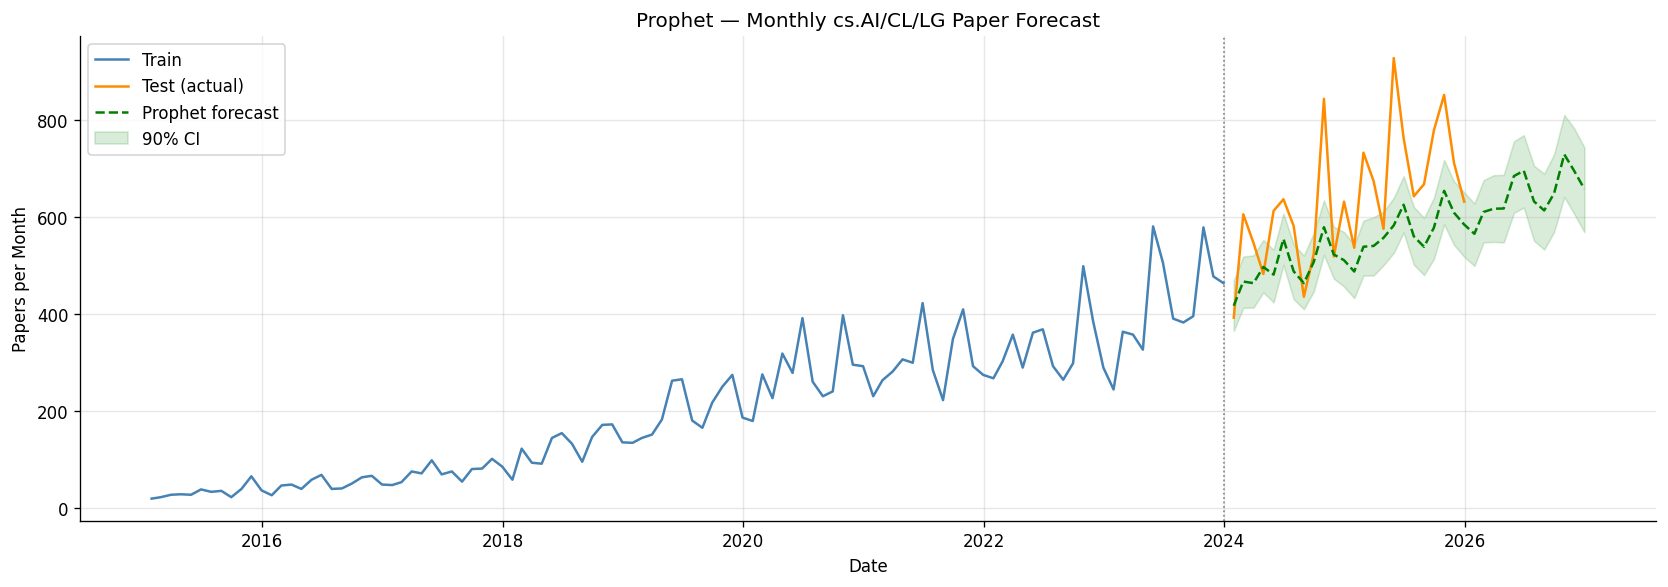


Prophet Test-set Metrics
  MAE  : 109.9 papers/month
  RMSE : 137.9 papers/month
  MAPE : 15.6%


In [20]:
future_df = prophet_model.make_future_dataframe(periods=N_FORECAST, freq='ME')
prophet_fc = prophet_model.predict(future_df)

# Align forecast to test window
prophet_test_fc = prophet_fc[prophet_fc['ds'] >= TEST_START].copy()
prophet_test_fc = prophet_test_fc.set_index('ds')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index, train, label='Train', color='steelblue', linewidth=1.5)
ax.plot(test.index,  test,  label='Test (actual)', color='darkorange', linewidth=1.5)
ax.plot(prophet_test_fc.index, prophet_test_fc['yhat'],
        label='Prophet forecast', color='green', linewidth=1.5, linestyle='--')
ax.fill_between(prophet_test_fc.index,
                prophet_test_fc['yhat_lower'],
                prophet_test_fc['yhat_upper'],
                color='green', alpha=0.15, label='90% CI')
ax.axvline(pd.Timestamp(TEST_START), color='grey', linestyle=':', linewidth=1)
ax.set_title('Prophet — Monthly cs.AI/CL/LG Paper Forecast', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Papers per Month')
ax.legend()
plt.tight_layout()
plt.show()

# Metrics
shared_idx  = test.index.intersection(prophet_test_fc.index)
p_actual    = test.loc[shared_idx]
p_forecast  = prophet_test_fc.loc[shared_idx, 'yhat']

p_mae  = mean_absolute_error(p_actual, p_forecast)
p_rmse = mean_squared_error(p_actual, p_forecast) ** 0.5
p_mape = np.mean(np.abs((p_actual - p_forecast) / p_actual.replace(0, np.nan))) * 100

print(f"\nProphet Test-set Metrics")
print(f"  MAE  : {p_mae:.1f} papers/month")
print(f"  RMSE : {p_rmse:.1f} papers/month")
print(f"  MAPE : {p_mape:.1f}%")

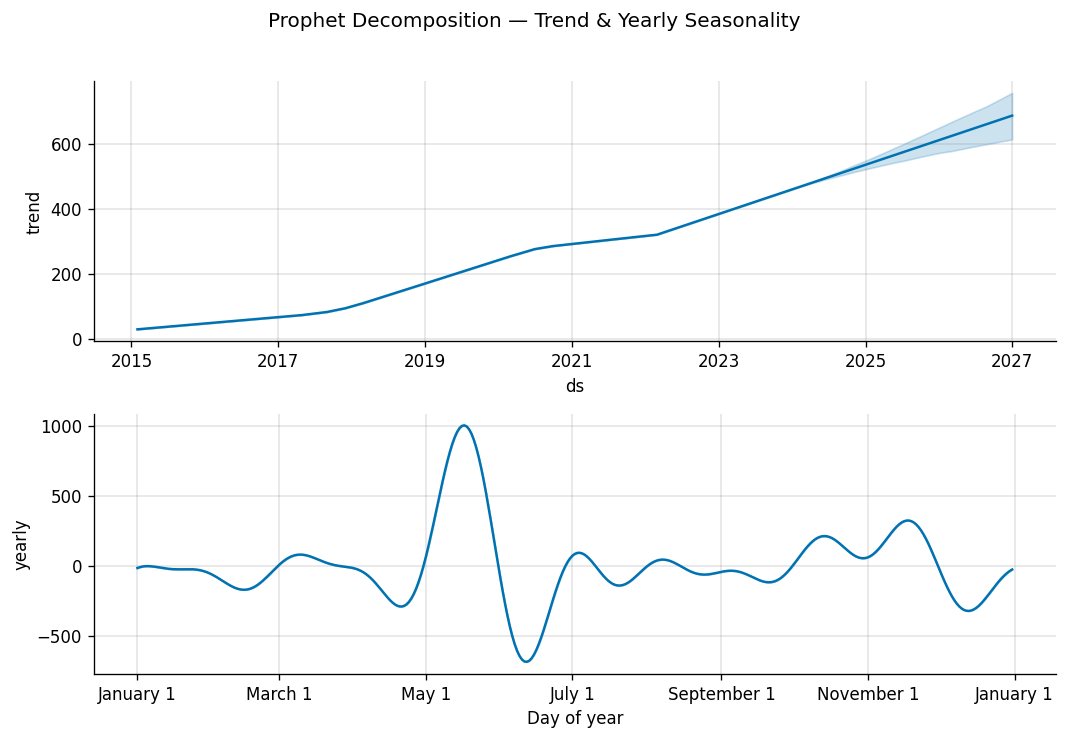

In [21]:
# Prophet component decomposition
fig = prophet_model.plot_components(prophet_fc)
fig.suptitle('Prophet Decomposition — Trend & Yearly Seasonality', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 12. Head-to-Head Model Comparison

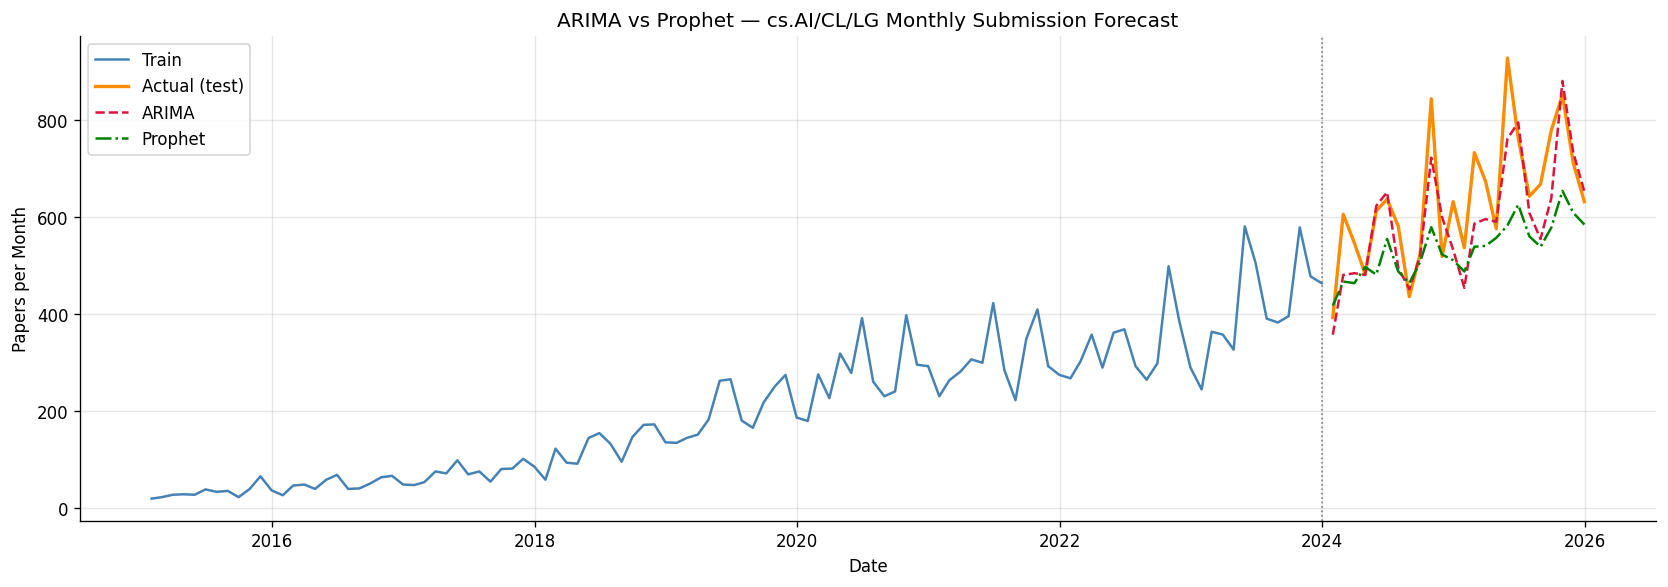


                         Model   MAE  RMSE  MAPE %
ARIMA SARIMA(1,1,1)(1,0,1)[12]  63.9  81.2    9.64
                       Prophet 109.9 137.9   15.63


In [22]:
# Side-by-side plot: both forecasts vs actuals
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(train.index, train,        color='steelblue',  linewidth=1.5, label='Train')
ax.plot(test.index,  test,         color='darkorange',  linewidth=2.0, label='Actual (test)')
ax.plot(arima_mean.index[:len(test)], arima_mean[:len(test)],
        color='crimson', linewidth=1.5, linestyle='--', label='ARIMA')
ax.plot(shared_idx, p_forecast,
        color='green',  linewidth=1.5, linestyle='-.',  label='Prophet')

ax.axvline(pd.Timestamp(TEST_START), color='grey', linestyle=':', linewidth=1)
ax.set_title('ARIMA vs Prophet — cs.AI/CL/LG Monthly Submission Forecast', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Papers per Month')
ax.legend()
plt.tight_layout()
plt.show()

# Metrics table
metrics = pd.DataFrame({
    'Model':  ['ARIMA SARIMA(1,1,1)(1,0,1)[12]', 'Prophet'],
    'MAE':    [round(mae, 1),   round(p_mae, 1)],
    'RMSE':   [round(rmse, 1),  round(p_rmse, 1)],
    'MAPE %': [round(mape, 2),  round(p_mape, 2)],
})
print("\n" + metrics.to_string(index=False))

## 13. Bonus — Keyword-Level Forecasting (LLM)

We apply Prophet to the raw monthly count of **LLM** mentions to illustrate
per-keyword forecasting.

20:00:09 - cmdstanpy - INFO - Chain [1] start processing
20:00:09 - cmdstanpy - INFO - Chain [1] done processing


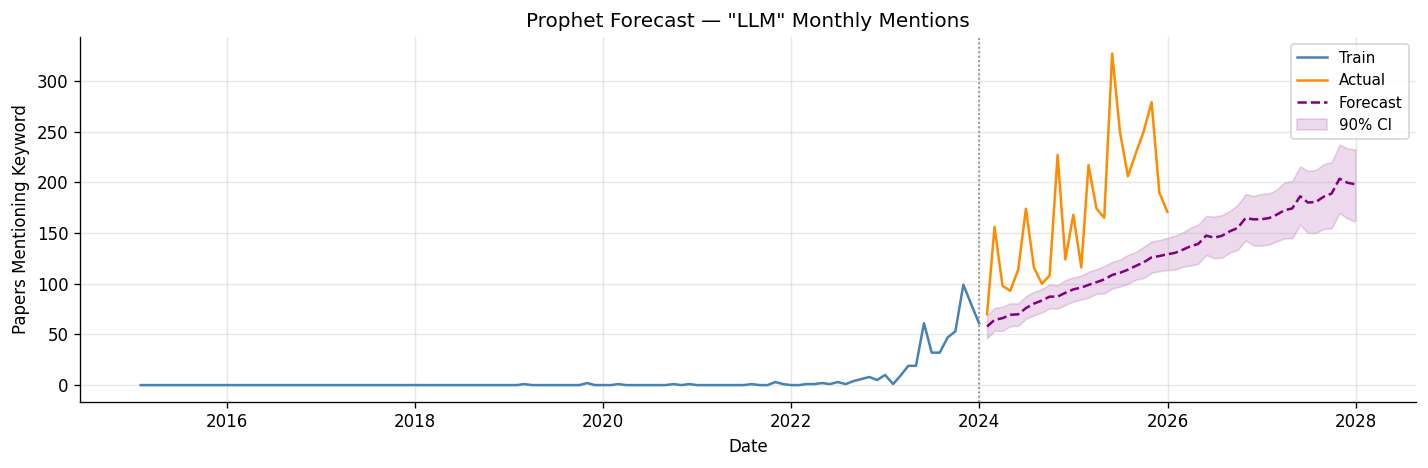

20:00:10 - cmdstanpy - INFO - Chain [1] start processing
20:00:10 - cmdstanpy - INFO - Chain [1] done processing


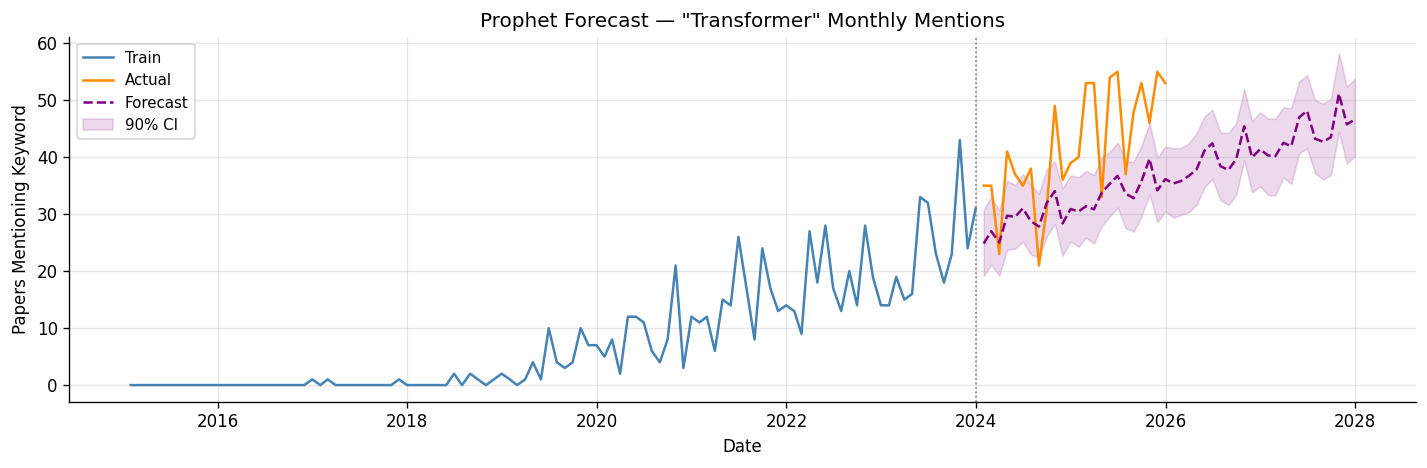

20:00:10 - cmdstanpy - INFO - Chain [1] start processing
20:00:10 - cmdstanpy - INFO - Chain [1] done processing


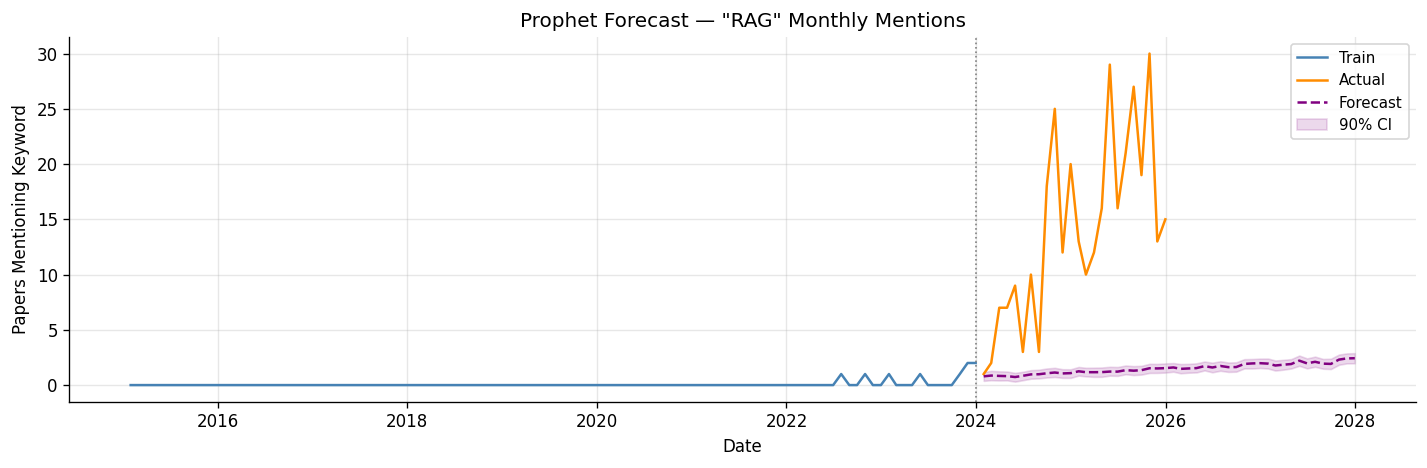

20:00:10 - cmdstanpy - INFO - Chain [1] start processing
20:00:10 - cmdstanpy - INFO - Chain [1] done processing


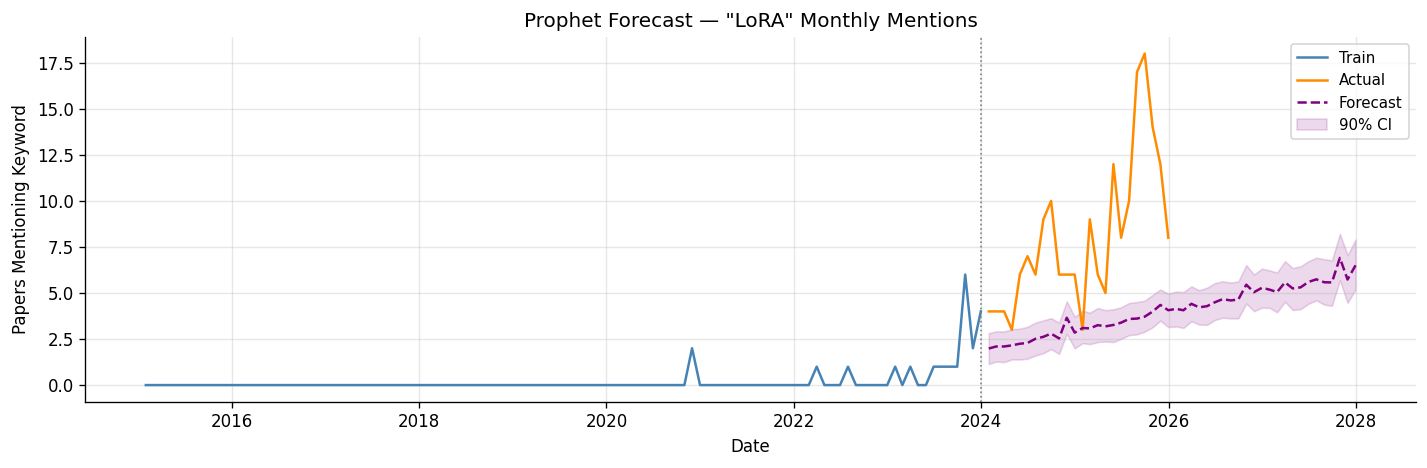

20:00:10 - cmdstanpy - INFO - Chain [1] start processing
20:00:11 - cmdstanpy - INFO - Chain [1] done processing


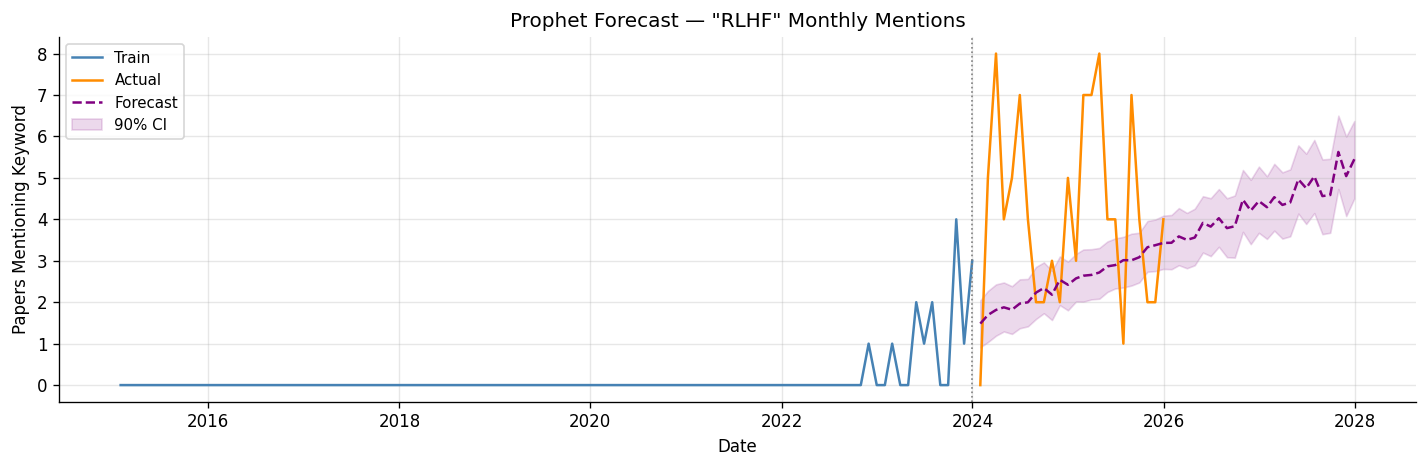

In [23]:
def forecast_keyword(kw: str, train_end: str = '2023-12-31', n_future: int = 24):
    """Fit a Prophet model on monthly keyword counts and plot a forecast."""
    kw_ts = monthly_kw.set_index('date')[kw].sort_index()
    kw_ts.index = pd.DatetimeIndex(kw_ts.index).to_period('M').to_timestamp('M')
    kw_ts = kw_ts[kw_ts.index >= '2015-01-01']

    kw_train = kw_ts[kw_ts.index <= train_end]
    kw_test  = kw_ts[kw_ts.index >  train_end]

    df_p = kw_train.reset_index().rename(columns={'date': 'ds', kw: 'y'})
    df_p['ds'] = pd.to_datetime(df_p['ds'])

    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.5,
        interval_width=0.90,
    )
    m.fit(df_p)

    future  = m.make_future_dataframe(periods=len(kw_test) + n_future, freq='ME')
    fc      = m.predict(future)
    fc_plot = fc[fc['ds'] > train_end].set_index('ds')

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(kw_train.index, kw_train, color='steelblue', linewidth=1.5, label='Train')
    if len(kw_test):
        ax.plot(kw_test.index, kw_test, color='darkorange', linewidth=1.5, label='Actual')
    ax.plot(fc_plot.index, fc_plot['yhat'],
            color='purple', linewidth=1.5, linestyle='--', label='Forecast')
    ax.fill_between(fc_plot.index, fc_plot['yhat_lower'], fc_plot['yhat_upper'],
                    color='purple', alpha=0.15, label='90% CI')
    ax.axvline(pd.Timestamp(train_end), color='grey', linestyle=':', linewidth=1)
    ax.set_title(f'Prophet Forecast — "{kw}" Monthly Mentions', fontsize=12)
    ax.set_xlabel('Date')
    ax.set_ylabel('Papers Mentioning Keyword')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


for kw in ['LLM', 'Transformer', 'RAG', 'LoRA', 'RLHF']:
    forecast_keyword(kw)

## 14. Summary

| Section | Key Finding |
|---------|-------------|
| **Data** | ~41 k cs.AI/CL/LG papers in the 10 % sample, 2007–2025 |
| **Volume** | Exponential growth since 2017; steep post-ChatGPT acceleration from late 2022 |
| **Transformer / LLM** | Near-zero pre-2017; dominant by 2022–2024 |
| **RLHF / LoRA / RAG** | Emerged 2022–2023; fastest YoY growth in 2023 |
| **ARIMA** | SARIMA(1,1,1)(1,0,1)[12] captures trend well; struggles with the post-2022 acceleration |
| **Prophet** | More flexible; better captures structural breaks via changepoints |
| **Keyword forecasts** | Prophet projects continued growth for LLM, RAG, LoRA into 2025–2026 |